51281
category
news            15774
sports          14510
finance          3107
foodanddrink     2551
lifestyle        2478
travel           2350
video            2068
weather          2048
health           1885
Name: count, dtype: int64


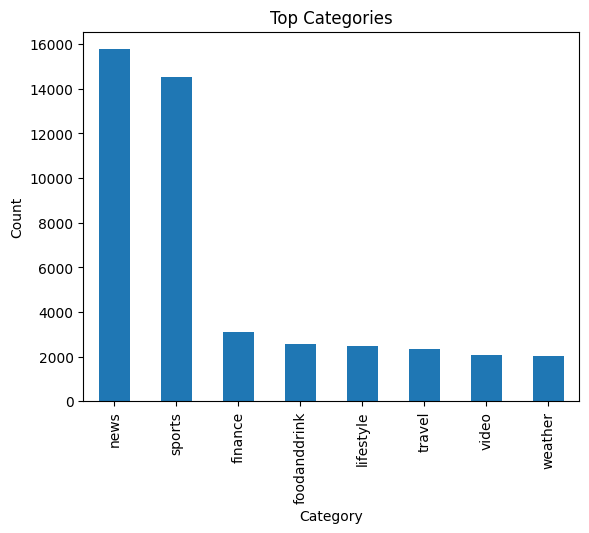

subcategory
newsus               6564
football_nfl         5420
newspolitics         2826
newscrime            2254
weathertopstories    2047
newsworld            1720
football_ncaa        1665
baseball_mlb         1661
basketball_nba       1555
Name: count, dtype: int64


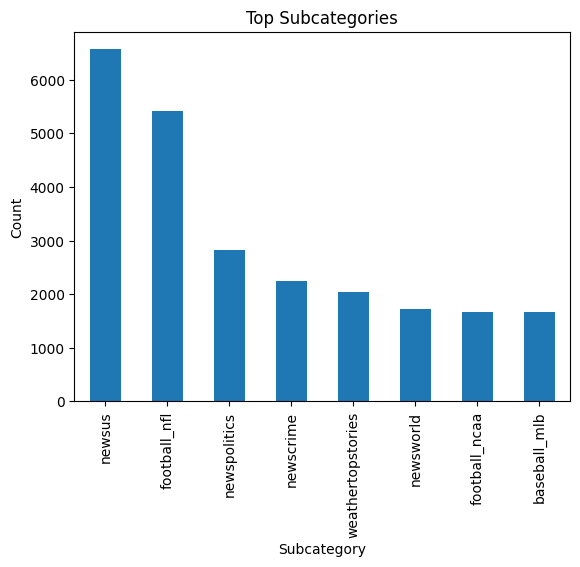

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


news = pd.read_csv('MINDsmall_train/news.tsv', sep='\t', header=0, names=['news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities'])
print(len(news))


print(news['category'].value_counts().head(8))

news['category'].value_counts().head(8).plot(kind='bar', title='Top Categories', xlabel='Category', ylabel='Count')
plt.show()


print(news['subcategory'].value_counts().head(9))
news['subcategory'].value_counts().head(8).plot(kind='bar', title='Top Subcategories', xlabel='Subcategory', ylabel='Count')
plt.show()

In [17]:

train = pd.read_csv('train.csv')
train.head(5)





,user_id,text,label
0,U14923,lifestyl shop-holiday here are biggest deal we...,0
1,U47945,foodanddrink foodnew thi chick-fil-a 's most-o...,0
2,U36010,video popcultur singer stand heckler told take...,1
3,U39247,entertain entertainment-celebr anna fari micha...,0
4,U69472,news newsworld photo day our top photo last 24...,0


In [ ]:
train[['category', 'subcategory', 'text_body']] = train['text'].str.split(' ', n=2, expand=True)
train.head(5)




,user_id,text,label,category,subcategory,text_body
0,U14923,lifestyl shop-holiday here are biggest deal we...,0,lifestyl,shop-holiday,here are biggest deal we 're anticip black fri...
1,U47945,foodanddrink foodnew thi chick-fil-a 's most-o...,0,foodanddrink,foodnew,thi chick-fil-a 's most-ord menu item there ma...
2,U36010,video popcultur singer stand heckler told take...,1,video,popcultur,singer stand heckler told take shirt after hec...
3,U39247,entertain entertainment-celebr anna fari micha...,0,entertain,entertainment-celebr,anna fari michael barrett may confirm engag pl...
4,U69472,news newsworld photo day our top photo last 24...,0,news,newsworld,photo day our top photo last 24 hour


In [ ]:



ctr_per_category = train.groupby('category')['label'].mean().sort_values(ascending=False)
print(ctr_per_category.head(5))

ctr_per_subcategory = train.groupby('subcategory')['label'].mean().sort_values(ascending=False)
print(ctr_per_subcategory.head(5))



category
middleeast    1.000000
tv            0.304001
movi          0.272860
sport         0.235165
video         0.220712
Name: label, dtype: float64
subcategory
golfvideo                      1.0
hollywood                      1.0
lifestyleshoppinghomegarden    1.0
lifestyleshop                  1.0
lifestylemarriag               1.0
Name: label, dtype: float64


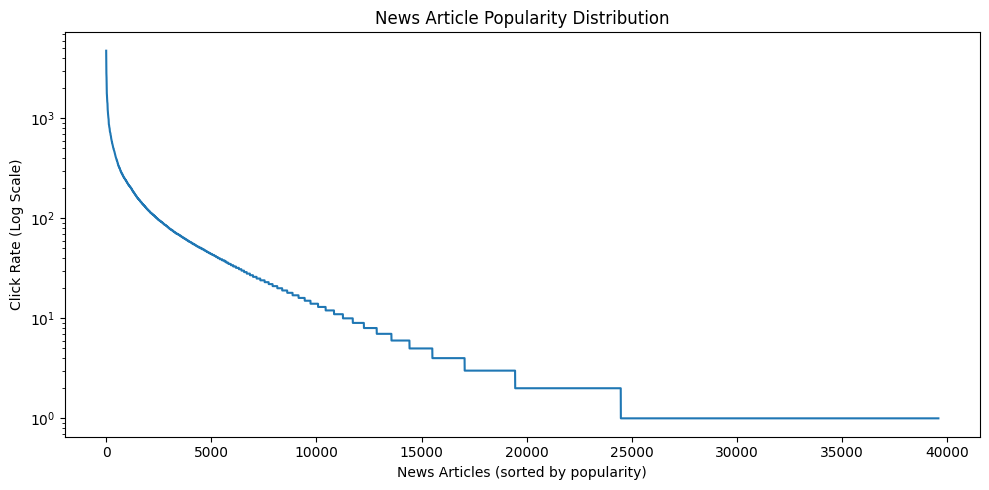

In [ ]:
item_popularity = train[train['label'] == 1]['text'].value_counts()


plt.figure(figsize=(10, 5))
plt.plot(range(len(item_popularity)), item_popularity.values)

plt.yscale('log')
plt.title('News Article Popularity Distribution')
plt.xlabel('News Articles (sorted by popularity)')
plt.ylabel('Click Rate (Log Scale)')
plt.tight_layout()
plt.show()


5948746
label
0    4799407
1    1149339
Name: count, dtype: int64


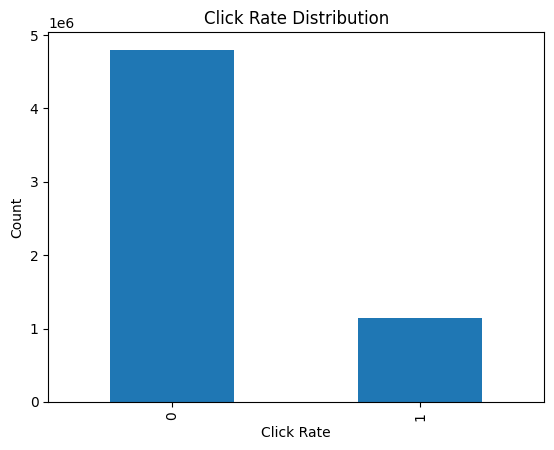

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')
print(len(train))
print(train['label'].value_counts())
train['label'].value_counts().plot(kind='bar', title='Click Rate Distribution', xlabel='Click Rate', ylabel='Count')
plt.show()

In [ ]:
num_users = train['user_id'].nunique()

average_user_interactions = len(train) / num_users
average_click_rate = len(train[train['label'] == 1]) / num_users
average_not_click_rate = len(train[train['label'] == 0]) / num_users

print(f"Number of users: {num_users}")  
print(f"Average user interaction: {average_user_interactions:.2f}")
print(f"Average click rate: {average_click_rate:.2f}")
print(f"Average not click rate: {average_not_click_rate:.2f}")


Number of users: 50000
Average click rate: 118.97
Average click rate: 22.99
Average not click rate: 95.99


In [10]:

# user with most interactions where label is 1
most_active_user = train[train['label'] == 1]['user_id'].value_counts().head(1)
print(f"Most active user: {most_active_user} ")
# least active user
least_active_user = train[train['label'] == 1]['user_id'].value_counts().tail(1)
print(f"Least active user: {least_active_user} ")


Most active user: user_id
U63482    658
Name: count, dtype: int64 
Least active user: user_id
U77106    2
Name: count, dtype: int64 
